In [1]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import numpy as np

In [2]:

# negocios = pl.read_csv("../data/negocios.csv")
# test_reviews = pl.read_csv("../data/test_reviews.csv")
# train_reviews = pl.read_csv("../data/train_reviews.csv")

# Usuarios

In [3]:
usuarios = (
    pl.read_csv("../data/usuarios.csv", try_parse_dates=True)
    .with_columns(
        pl.when(
            pl.col("friends").is_null() | pl.col("friends").is_in(["None", ""])
        )
        .then(pl.lit([]).cast(pl.List(pl.Utf8)))
        .otherwise(pl.col("friends").str.split(",").list.eval(pl.element().str.strip_chars()))
        .alias("friends"),
        pl.when(
            pl.col("elite").is_null() | pl.col("elite").is_in(["None", ""])
        )
        .then(pl.lit([]).cast(pl.List(pl.Utf8)))
        .otherwise(pl.col("elite").str.split(",").list.eval(pl.element().str.strip_chars()))
        .alias("elite")
    )
)
usuarios.head(5)

user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
str,str,i64,datetime[μs],i64,i64,i64,list[str],list[str],i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""qVc8ODYU5SZjKXVBgXdI7w""","""Walker""",585,2007-01-25 16:47:26,7217,1259,5994,"[""2007""]","[""NSCy54eWehBJyZdG2iE84w"", ""pe42u7DcCH2QmI81NX-8qA"", … ""mEjPkT-wxU8kBm2zj2Cmzw""]",267,3.91,250,65,55,56,18,232,844,467,467,239,180
"""j14WgRoU_-2ZE1aw1dXrJg""","""Daniel""",4333,2009-01-25 04:35:42,43091,13066,27281,"[""2009"", ""2010"", … ""2021""]","[""ueRPE0CX75ePGMqOFVj6IQ"", ""52oH4DrRvzzl8wh5UXyU0A"", … ""4tWyQ6sykZf1qzJydWtgqw""]",3138,3.74,1145,264,184,157,251,1847,7054,3131,3131,1521,1946
"""2WnXYQFK0hXEoTxPtV2zvg""","""Steph""",665,2008-07-25 10:41:00,2086,1010,1003,"[""2009"", ""2010"", … ""2013""]","[""LuO3Bn4f3rlhyHIaNfTlnA"", ""j9B4XdHUhDfTKVecyWQgyA"", … ""n8UuPQ-nodu1xMHQheGsfg""]",52,3.32,89,13,10,17,3,66,96,119,119,35,18
"""SZDeASXq7o05mMNLshsdIA""","""Gwen""",224,2005-11-29 04:38:33,512,330,299,"[""2009"", ""2010"", ""2011""]","[""enx1vVPnfdNUdPho6PH_wg"", ""4wOcvMLtU6a9Lslggq74Vg"", … ""7BSP1GSsJkiEXvA3dOPx_Q""]",28,4.27,24,4,1,6,2,12,16,26,26,10,9
"""q_QQ5kBBwlCcbL1s4NVK3g""","""Jane""",1221,2005-03-14 20:26:35,14953,9940,11211,"[""2006"", ""2007"", … ""2014""]","[""xBDpTUbai0DXrvxCe3X16Q"", ""7GPNBO496aecrjJfW6UWtg"", … ""KLrTBLpN4csEWKdLX2meYQ""]",1357,3.85,1713,163,191,361,147,1212,5696,2543,2543,815,323


In [4]:
duckdb.sql("""
SELECT SUM(review_count) AS total_reviews, AVG(review_count) AS avg_reviews_per_user, COUNT(DISTINCT user_id) AS total_users, MAX(yelping_since) AS newest_user_registration, MIN(yelping_since) AS oldest_user_registration
FROM usuarios
""")

┌───────────────┬──────────────────────┬─────────────┬──────────────────────────┬──────────────────────────┐
│ total_reviews │ avg_reviews_per_user │ total_users │ newest_user_registration │ oldest_user_registration │
│    int128     │        double        │    int64    │        timestamp         │        timestamp         │
├───────────────┼──────────────────────┼─────────────┼──────────────────────────┼──────────────────────────┤
│      25996773 │    37.15847196831418 │      699619 │ 2022-01-19 17:15:47      │ 2004-10-12 08:46:11      │
└───────────────┴──────────────────────┴─────────────┴──────────────────────────┴──────────────────────────┘

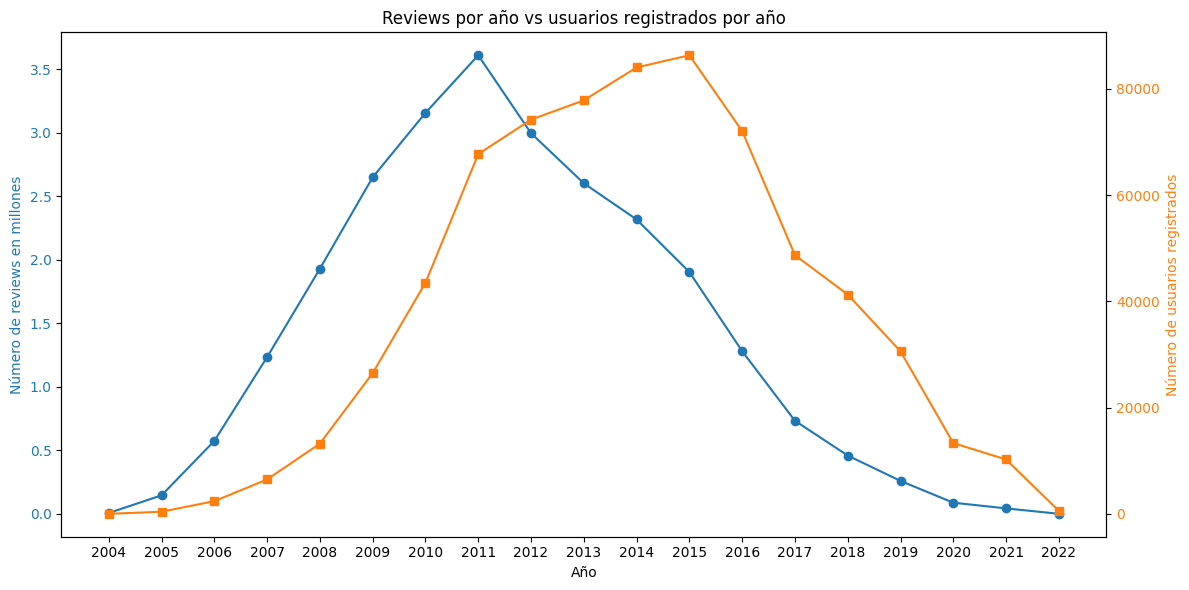

In [48]:
import matplotlib.pyplot as plt

usuarios_anio = usuarios.with_columns(
    pl.col("yelping_since").dt.year().alias("anio")
)

df_plot = (
    duckdb.sql("""
        SELECT
            anio,
            COUNT(*) AS usuarios_registrados,
            SUM(review_count) AS total_reviews
        FROM usuarios_anio
        GROUP BY anio
        ORDER BY anio
    """)
    .pl()
    .with_columns(
        pl.col("anio").cast(pl.Utf8),  # fuerza mostrar años completos en eje X
        (pl.col("total_reviews").cast(pl.Float64) / 1_000_000).alias("total_reviews"),  # eje Y azul en millones
    )
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    df_plot["anio"].to_numpy(),
    df_plot["total_reviews"].to_numpy(),
    marker="o",
    color="tab:blue",
    label="Reviews"
)
ax1.set_xlabel("Año")
ax1.set_ylabel("Número de reviews en millones", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(
    df_plot["anio"].to_numpy(),
    df_plot["usuarios_registrados"].to_numpy(),
    marker="s",
    color="tab:orange",
    label="Usuarios registrados"
)
ax2.set_ylabel("Número de usuarios registrados", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Reviews por año vs usuarios registrados por año")
fig.tight_layout()
plt.show()

### Distribuciuon de calificaicones.

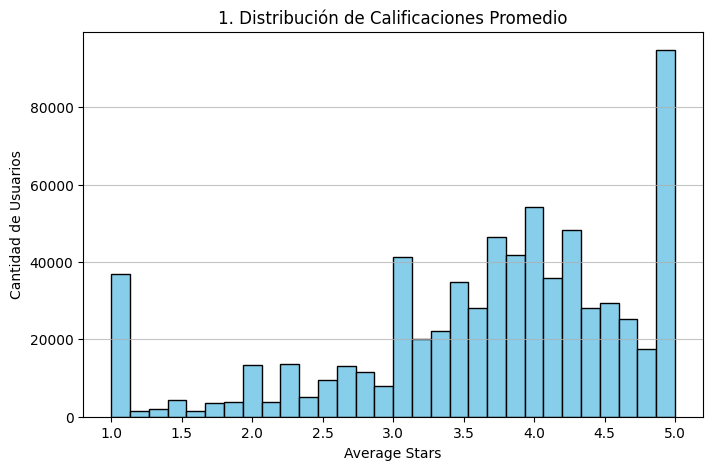

In [13]:
plt.figure(figsize=(8, 5))
data = duckdb.sql("SELECT average_stars FROM usuarios WHERE average_stars IS NOT NULL").pl()
plt.hist(data['average_stars'], bins=30, color='skyblue', edgecolor='black')
plt.title('1. Distribución de Calificaciones Promedio')
plt.xlabel('Average Stars')
plt.ylabel('Cantidad de Usuarios')
plt.grid(axis='y', alpha=0.75)
plt.show()

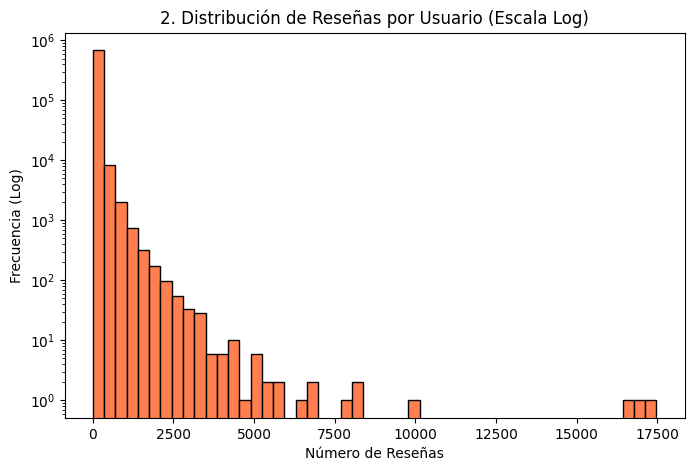

In [14]:
plt.figure(figsize=(8, 5))
data = duckdb.sql("SELECT review_count FROM usuarios WHERE review_count > 0").pl()
plt.hist(data['review_count'], bins=50, color='coral', log=True, edgecolor='black')
plt.title('2. Distribución de Reseñas por Usuario (Escala Log)')
plt.xlabel('Número de Reseñas')
plt.ylabel('Frecuencia (Log)')
plt.show()

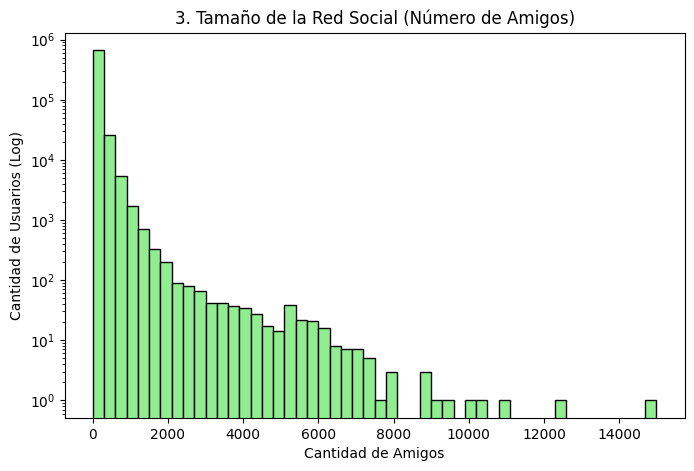

In [20]:
plt.figure(figsize=(8, 5))
data = duckdb.sql("SELECT length(friends) as num_friends FROM usuarios").pl()
plt.hist(data['num_friends'], bins=50, color='lightgreen', log=True, edgecolor='black')
plt.title('3. Tamaño de la Red Social (Número de Amigos)')
plt.xlabel('Cantidad de Amigos')
plt.ylabel('Cantidad de Usuarios (Log)')
plt.show()

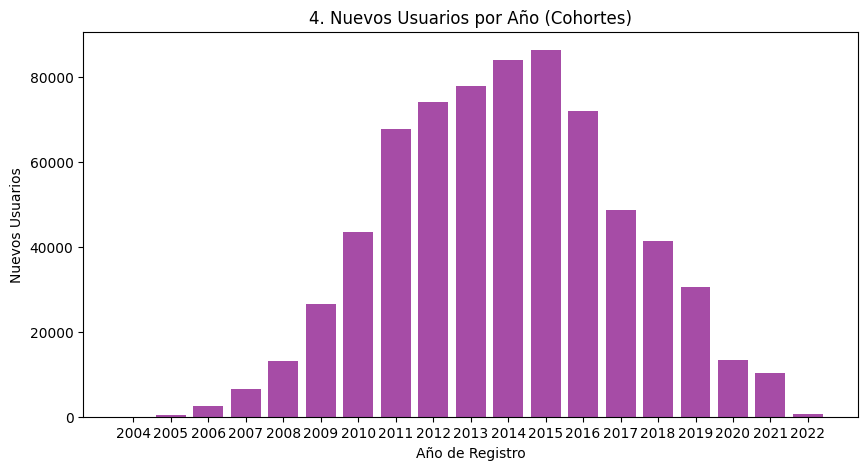

In [24]:
plt.figure(figsize=(10, 5))
data = duckdb.sql("""
    SELECT EXTRACT(year FROM yelping_since) as join_year, COUNT(*) as user_count 
    FROM usuarios 
    GROUP BY join_year 
    ORDER BY join_year
""").pl()

plt.bar(data['join_year'], data['user_count'], color='purple', alpha=0.7)
plt.xticks(data['join_year'].to_list())
plt.title('4. Nuevos Usuarios por Año (Cohortes)')
plt.xlabel('Año de Registro')
plt.ylabel('Nuevos Usuarios')
plt.show()

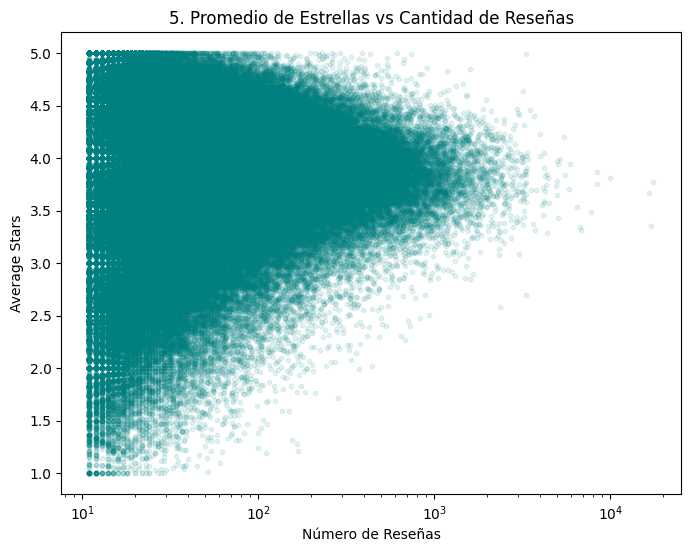

In [25]:
plt.figure(figsize=(8, 6))
data = duckdb.sql("SELECT review_count, average_stars FROM usuarios WHERE review_count > 10").pl()
plt.scatter(data['review_count'], data['average_stars'], alpha=0.1, color='teal', s=10)
plt.title('5. Promedio de Estrellas vs Cantidad de Reseñas')
plt.xlabel('Número de Reseñas')
plt.ylabel('Average Stars')
plt.xscale('log')
plt.show()

/tmp/ipykernel_23701/2740232827.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([np.log1p(data['useful']), np.log1p(data['funny']), np.log1p(data['cool'])],


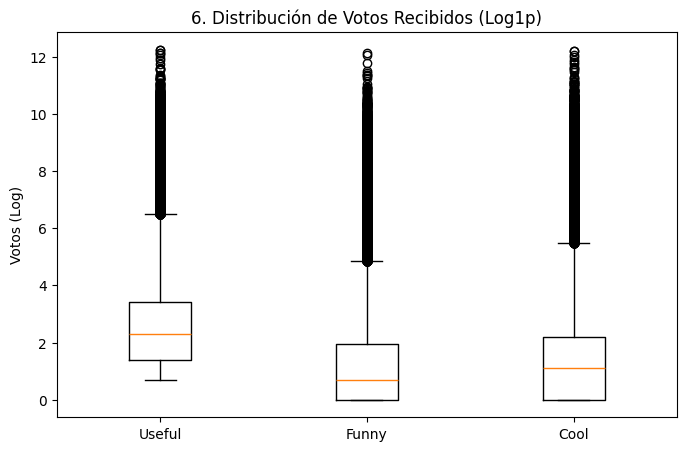

In [26]:
plt.figure(figsize=(8, 5))
data = duckdb.sql("SELECT useful, funny, cool FROM usuarios WHERE useful > 0").pl()
plt.boxplot([np.log1p(data['useful']), np.log1p(data['funny']), np.log1p(data['cool'])], 
            labels=['Useful', 'Funny', 'Cool'])
plt.title('6. Distribución de Votos Recibidos (Log1p)')
plt.ylabel('Votos (Log)')
plt.show()

/tmp/ipykernel_23701/3355346442.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([np.log1p(normal_counts), np.log1p(elite_counts)], labels=['Normal', 'Elite'])


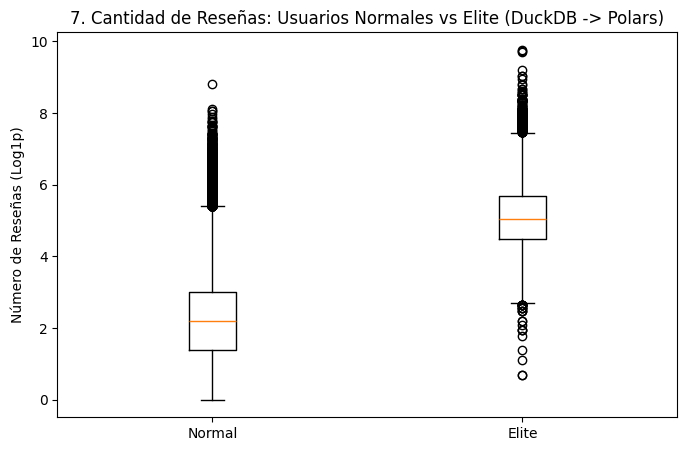

In [45]:
# 1. Consulta SQL con DuckDB y exportación directa a Polars usando .pl()
# Derivemos la columna 'status' directamente dentro de la consulta SQL para optimizar
query_status = """
    SELECT 
        review_count, 
        CASE 
            WHEN len(elite) > 0 THEN 'Elite' 
            ELSE 'Normal' 
        END as status
    FROM usuarios
    WHERE review_count IS NOT NULL -- excluimos nulos para la transformación logarítmica
"""

# df_status_pl es ahora un DataFrame de Polars (Cero copias, integración via Arrow)
df_status_pl = duckdb.sql(query_status).pl()

# 2. Extracción eficiente de los datos para Matplotlib (usando NumPy)
# Filtramos y convertimos a numpy array directamente desde la columna Series de Polars
elite_counts = (
    df_status_pl
    .filter(pl.col("status") == "Elite")
    .get_column("review_count")
    .to_numpy()
)

normal_counts = (
    df_status_pl
    .filter(pl.col("status") == "Normal")
    .get_column("review_count")
    .to_numpy()
)

# 3. Visualización con Matplotlib
plt.figure(figsize=(8, 5))

# Creamos los boxplots usando log1p para manejar ceros y visualizar mejor la distribución sesgada
# Usamos log1p(normal_counts) y log1p(elite_counts) para la transformación logarítmica
plt.boxplot([np.log1p(normal_counts), np.log1p(elite_counts)], labels=['Normal', 'Elite'])

# Configuramos título y etiquetas en español
plt.title('7. Cantidad de Reseñas: Usuarios Normales vs Elite (DuckDB -> Polars)')
plt.ylabel('Número de Reseñas (Log1p)')

# Mostramos el gráfico
plt.show()

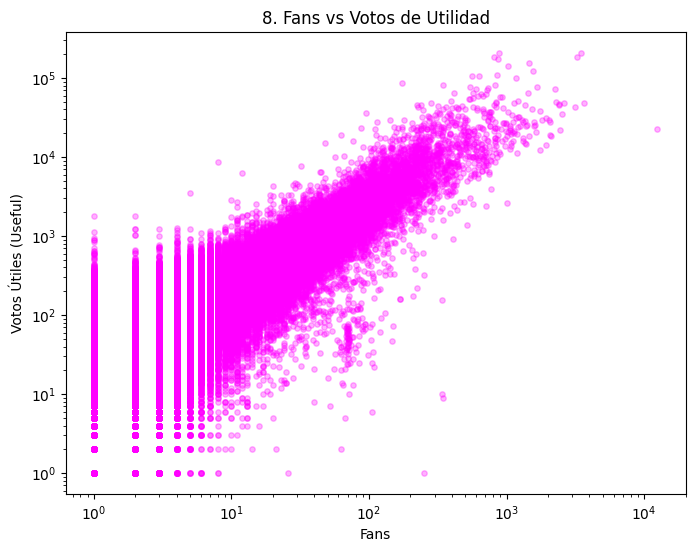

In [35]:
plt.figure(figsize=(8, 6))
data = duckdb.sql("SELECT fans, useful FROM usuarios WHERE fans > 0 AND useful > 0").pl()
plt.scatter(data['fans'], data['useful'], alpha=0.3, color='magenta', s=15)
plt.title('8. Fans vs Votos de Utilidad')
plt.xlabel('Fans')
plt.ylabel('Votos Útiles (Useful)')
plt.xscale('log')
plt.yscale('log')
plt.show()

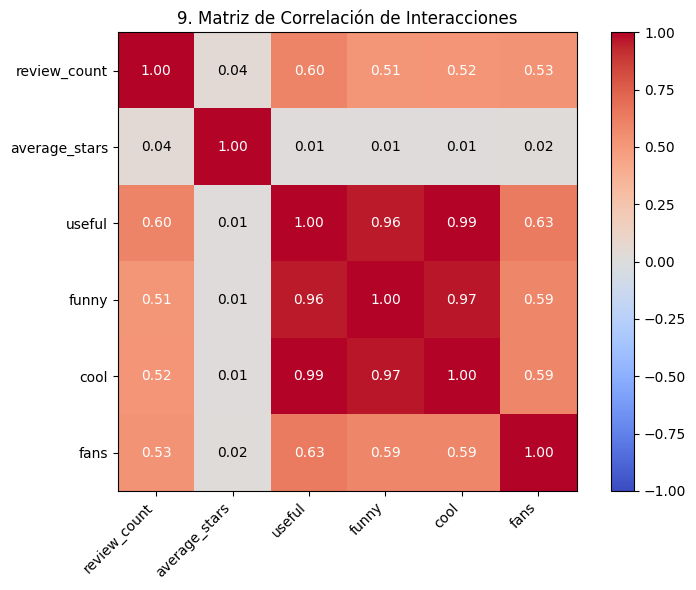

In [43]:
# 1. Consulta SQL con DuckDB y exportación directa a Polars usando .pl()
# Usamos solo las columnas originales de tu dataset
query = """
    SELECT 
        review_count, 
        average_stars, 
        useful, 
        funny, 
        cool, 
        fans 
    FROM usuarios
"""

# df_corr es ahora un DataFrame de Polars (Cero copias, integración via Arrow)
df_corr = duckdb.sql(query).pl()

# 2. Cálculo de la matriz de correlación
# Extraemos los nombres de las columnas para las etiquetas
column_names = df_corr.columns

# Pasamos los datos a NumPy de forma eficiente para calcular la correlación
# rowvar=False indica que las columnas son las variables (features)
corr_matrix = np.corrcoef(df_corr.to_numpy(), rowvar=False)

# 3. Visualización con Matplotlib
plt.figure(figsize=(8, 6))

# Dibujamos el mapa de calor (heatmap)
cax = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(cax)

# Configuramos las etiquetas de los ejes X e Y
ticks = np.arange(0, len(column_names), 1)
plt.xticks(ticks, column_names, rotation=45, ha='right')
plt.yticks(ticks, column_names)

plt.title('9. Matriz de Correlación de Interacciones')

# Añadimos los valores numéricos dentro de cada celda para que sea legible
for i in range(len(column_names)):
    for j in range(len(column_names)):
        # Añadimos el valor redondeado a 2 decimales
        plt.text(j, i, f"{corr_matrix[i, j]:.2f}", 
                 ha="center", va="center", color="black" if abs(corr_matrix[i, j]) < 0.5 else "white")

# Ajustamos el layout para que los textos rotados no se corten
plt.tight_layout()
plt.show()

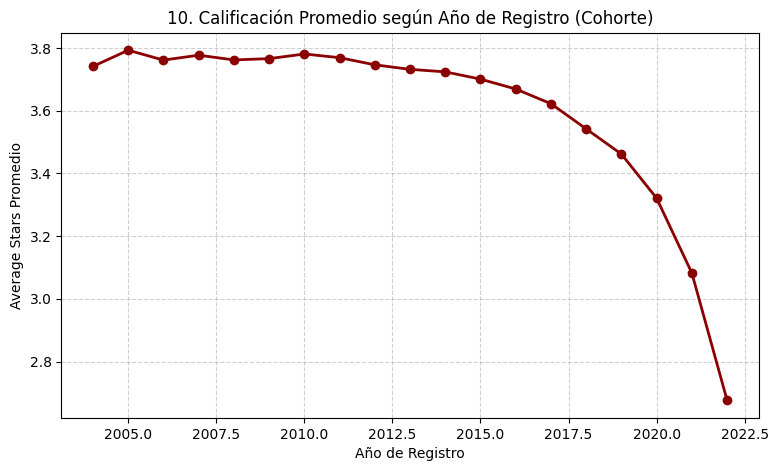

In [40]:
plt.figure(figsize=(9, 5))
data = duckdb.sql("""
    SELECT EXTRACT(year FROM yelping_since) as join_year, AVG(average_stars) as mean_stars 
    FROM usuarios
    GROUP BY join_year 
    ORDER BY join_year
""").pl()

plt.plot(data['join_year'], data['mean_stars'], marker='o', linestyle='-', color='darkred', linewidth=2)
plt.title('10. Calificación Promedio según Año de Registro (Cohorte)')
plt.xlabel('Año de Registro')
plt.ylabel('Average Stars Promedio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Negocios